# Gamma transmission plotter - multiple materials

Maggie Tseng  
Last updated: ~~Oct 20, 2025~~ --> Apr 8, 2026
(Second plot regenerated to include Pb and Ta on Apr 8, 2026)

This notebook does nearly the same thing as gamma_transmission_plotter.ipynb but includes multiple materials on each plot: 

1. Reproduction of Henke's plots of gamma attenuation length as a function of photon energy
2. Gamma transmission as a function of photon energy

Note that the text files provided by Henke must be slightly modified by hand to be used here: put two spaces (instead of comma + space) between the header labels in the second line.

Henke data at: https://henke.lbl.gov/optical_constants/atten2.html  
(enter material name/chem formula, density -1 to use tabulated values, scan photon range from 30 to 120 in 90 steps)

Transmission equation: fraction of surviving photons = exp(- dist traveled by photon / attentuation length given by Henke), which can be written: 
$$T = \exp(-x/ \ell)$$

Note that the second plot here (showing transmission of gammas through Be, Al, and Si) looks like an exact reproduction of Adrian's first plot from elog:Pa229/9, except my plots show a smaller range of photon energies. So far, Al and Be look like the highest-transmission candidates (for implantation depths of 0.333 um and 2 um).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

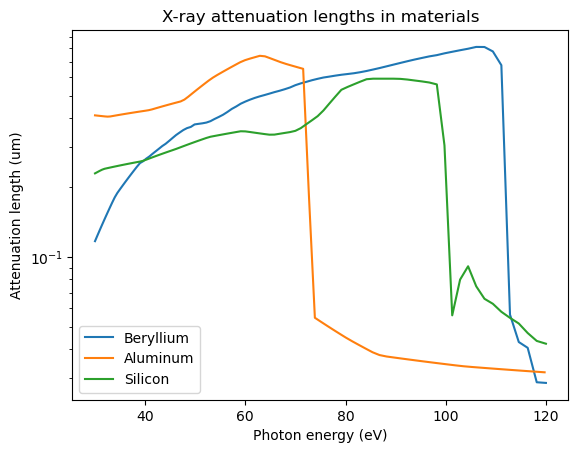

In [2]:
fig_l, ax_l = plt.subplots()
ax_l.set_title(f"X-ray attenuation lengths in materials")
ax_l.set_xlabel("Photon energy (eV)")
ax_l.set_ylabel("Attenuation length (um)")
ax_l.set_yscale("log")

def add_material_l(material_name, material_shortname):
    filepath = f"Henke_data/xray_{material_shortname}.dat"
    df_material = pd.read_csv(filepath, header=1, sep="  ", engine="python")
    df_material.rename(columns={'Photon Energy (eV)': 'energy', 'Atten Length (microns)': 'attn_length'}, inplace=True)
    energy = df_material["energy"]
    attn_length = df_material["attn_length"]

    ax_l.plot(energy, attn_length, label=material_name)
    # ax_l.legend()

add_material_l("Beryllium", "Be")
# add_material_l("Carbon", "C")
add_material_l("Aluminum", "Al")
add_material_l("Silicon", "Si")
# add_material_l("Tantalum", "Ta")
# add_material_l("Lead", "Pb")

ax_l.legend();

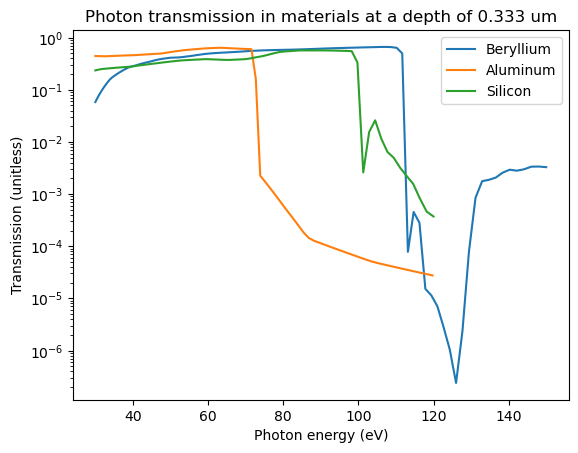

In [80]:
# todo - put this definition somewhere logical
# todo - maybe allow for possibility of comparing transmission for diff materials at diff depths? (not sure if this is something that makes sense to compare?)
implantation_depth = 0.333 # um

fig_t, ax_t = plt.subplots()
ax_t.set_title(f"Photon transmission in materials at a depth of {implantation_depth} um")
ax_t.set_xlabel("Photon energy (eV)")
ax_t.set_ylabel("Transmission (unitless)")
ax_t.set_yscale("log")

def add_material_t(material_name, material_shortname):
    filepath = f"Henke_data/xray_{material_shortname}.dat"
    df_material = pd.read_csv(filepath, header=1, sep="  ", engine="python")
    df_material.rename(columns={'Photon Energy (eV)': 'energy', 'Atten Length (microns)': 'attn_length'}, inplace=True)
    energy = df_material["energy"]
    attn_length = df_material["attn_length"]

    transmission = np.exp(-1 * implantation_depth / attn_length)

    ax_t.plot(energy, transmission, label=material_name)
    # ax_t.legend()

add_material_t("Beryllium", "Be")
# add_material_t("Carbon", "C")
add_material_t("Aluminum", "Al")
add_material_t("Silicon", "Si")
# add_material_t("Tantalum", "Ta")
# add_material_t("Lead", "Pb")

ax_t.legend();

In [72]:
# Function to allow us to check the transmission for a single given material, implantation depth, and photon energy)
# todo - define this function to take a range of photon energies? For now, that can be done using a Python list comprehension instead, as in next cell
def check_transmission(material_name, material_shortname, impl_depth, photon_energy):
    filepath = f"Henke_data/xray_{material_shortname}.dat"
    df_material = pd.read_csv(filepath, header=1, sep="  ", engine="python")
    df_material.rename(columns={'Photon Energy (eV)': 'energy', 'Atten Length (microns)': 'attn_length'}, inplace=True)
    energy = df_material["energy"]
    attn_length = df_material["attn_length"]

    # Fix gamma energy at photon_energy, then (linearly) interpolate Henke data at that energy to get one particular attn length
    # This snippet is modified from gamma_transmission_plotter.ipynb (fixed so that it works for photon_energy = 30 and photon_energy=120)
    index = np.searchsorted(energy, photon_energy)
    if photon_energy==30:
        attnlength = attn_length[index]
    elif photon_energy==120:
        attnlength = attn_length[index-1]
    else:
        m = (attn_length[index] - attn_length[index-1])/(energy[index] - energy[index-1])
        attnlength = m * (60 - energy[index]) + attn_length[index]
    # print(attnlength)

    transmission = np.exp(-1 * impl_depth / attnlength)
    return transmission

In [73]:
# The highest transmission found here is for 72 eV photon through 0.333 Al, for which the transmission is 93% (very high!)

check_transmission("Aluminum", "Al", 0.333, 72)
# [check_transmission("Aluminum","Al",0.333, some_energy) for some_energy in range(30,120)]
# np.max( [check_transmission("Aluminum","Al",0.333, some_energy) for some_energy in range(30,120)] )
# np.argmax( [check_transmission("Aluminum","Al",0.333, some_energy) for some_energy in range(30,120)] )

0.9393255336114756

In [76]:
# Transmission is still pretty high (63%) for a 60 eV photon through 0.333 um of Al.
check_transmission("Aluminum","Al",0.333,60)

0.6262887085683134